## 🚢 Predicting Titanic Survival Using Several ML Models
### A Machine Learning Approach to Disaster Analysis

### Business Problem:
##### Can we presict survival outcomes using passenger demographics and socio-economic data?

##### This model isn't just historical -- it mirrors modern use csaes like:

##### -__Emergency Preparedness:__ Priortizing vulnerable groups (children, elderly) in evacuation plans.
##### -__Bias Investigation:__ Quantifying how class, gender, and age affected survival
##### -__Safety Benchmarking:__ Evaluation if "women and children first" was truly followed.

### Key Workflows Steps:

##### 1. __Feature Selection:__ Focused on Pclass, Sex, Age and Fare (critical factors proven in history analysis).
##### 2. __Data Prep:__

#####   - Convert categorical data (e.g., sex to 0/1)
#####   - Handle missingvalues (e.g., median imputation for Age).
##### 3. __Model Evaluation:__ Metrics like accuracy, precision and recall to assess real-world usability.

##### __Challenge to Audience:__ Could a passenger's fare price indirectly reveal their survival odds? Let's find out

## 1. Import Libraries

In [1]:
# Step 1: Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer #To handle missing values
from src.visualization import plot_feature_importance, plot_correlation_heatmap, plot_survival_distribution


## 2. Load Dataset

In [2]:
# Step 2: Load the Titanic Dataset
df = pd.read_csv('data/titanic.csv')

# Preview
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


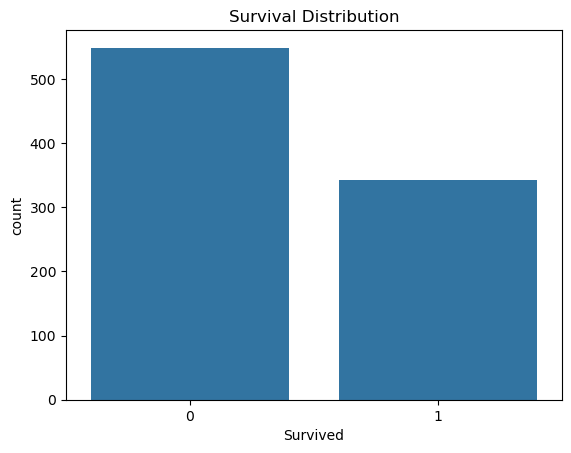

In [3]:
plot_survival_distribution(df, save_path="assets/survival_distribution.png")

## 3. Separate features and target

In [4]:
# Feature Engineering is already done in clean_data()
from src.clean_data import clean_data
X, y = clean_data('data/titanic.csv')


In [5]:
# Now X is a NumPy array with no missing values

import numpy as np
np.isnan(X).any()

Pclass        False
Sex           False
Age           False
Fare          False
FamilySize    False
IsAlone       False
Title         False
AgeGroup      False
FareBin       False
dtype: bool

In [6]:
X.head()

,Pclass,Sex,Age,Fare,FamilySize,IsAlone,Title,AgeGroup,FareBin
0,3,1,22.0,7.2500,2,0,1.0,2,0
1,1,0,38.0,71.2833,2,0,3.0,2,3
2,3,0,26.0,7.9250,1,1,2.0,2,1
3,1,0,35.0,53.1000,2,0,3.0,2,3
4,3,1,35.0,8.0500,1,1,1.0,2,1


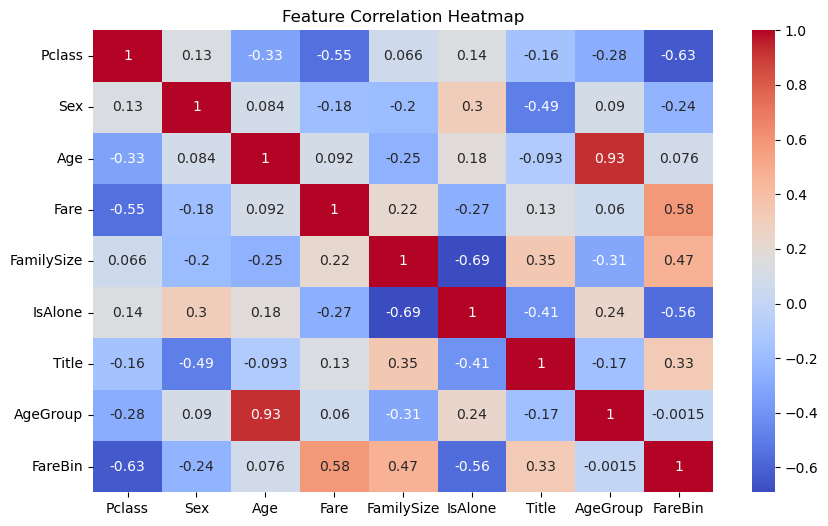

In [7]:
plot_correlation_heatmap(X, save_path="assets/correlation_heatmap.png")

In [8]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## 4. Train and test split

In [9]:
# Step 5: Split into train and test sets
# Train test split (80% train, 20% test)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [10]:
# from src.hyperparameter_tuning import tuning

# rf_grid = tuning(X_train, y_train)

# {'max_depth': 8, 'max_features': 0.2, 'max_samples': 0.5, 'n_estimators': 60}
#    |
#    |==> This gives 0.84 as a best score

## 5. Train and Evaluate Models

In [11]:
from src.train_models import train_and_evaluate_models

models, results_df = train_and_evaluate_models(X_train, X_test, y_train, y_test)

results_df

,Model,Accuracy,Recall,F1 Score
0,Random Forest,0.82,0.72,0.76
1,Logistic Regression,0.79,0.73,0.74
2,Naive Bayes,0.75,0.68,0.69


## 6. Tune Top Models

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from src.hyperparameter_tuning import tuning_top_models
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


models_with_params = {

    # ✅ Logistic Regression with scaling
    "Logistic Regression": (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression())
        ]),
        {
            'model__C': [0.01, 0.1, 1, 10],
            'model__max_iter': [500, 1000],
            "model__penalty": ["l2"],
            'model__solver': ['lbfgs']
        }
        ),

    # ✅ Random Forest (no scaling needed)
    "Random Forest": (
        RandomForestClassifier(),
        {
            'n_estimators': [20, 60, 100],
            'max_depth': [2, 8, None],
            'max_features': [0.2, 0.6, 1.0],
            'max_samples': [0.5, 0.75, 1.0]
        }
    )
}

best_models = tuning_top_models(X_train, y_train, models_with_params)


🔍 Tuning Logistic Regression...
Param Grid: {'model__C': [0.01, 0.1, 1, 10], 'model__max_iter': [500, 1000], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']} 

Fitting 5 folds for each of 8 candidates, totalling 40 fits

✅ Best Params for Logistic Regression: {'model__C': 0.1, 'model__max_iter': 500, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
⭐ Best CV Score: 81.74%

🔍 Tuning Random Forest...
Param Grid: {'n_estimators': [20, 60, 100], 'max_depth': [2, 8, None], 'max_features': [0.2, 0.6, 1.0], 'max_samples': [0.5, 0.75, 1.0]} 

Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Best Params for Random Forest: {'max_depth': 8, 'max_features': 0.6, 'max_samples': 0.75, 'n_estimators': 20}
⭐ Best CV Score: 83.42%


## 7. 📊 Evaluate

Logistic Regression → Accuracy: 0.79, F1: 0.74
Random Forest → Accuracy: 0.83, F1: 0.77

🏆 Final Best Model: Random Forest


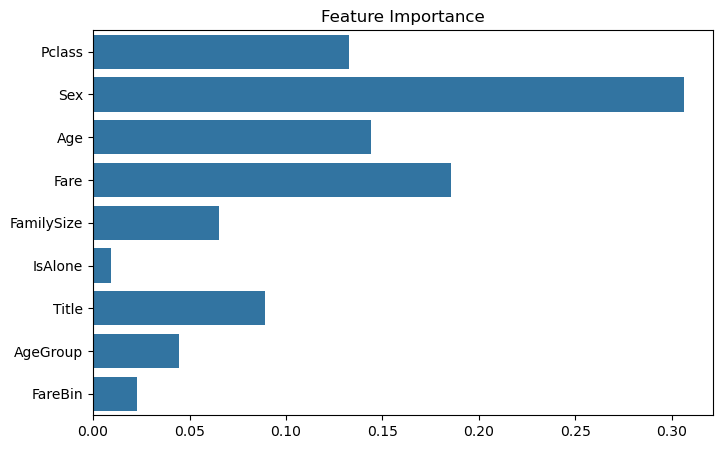

In [13]:
from src.best_model import select_best_model

best_model, best_model_name = select_best_model(best_models, X_test, y_test)

feature_names = [
    "Pclass", "Sex", "Age", "Fare",
    "FamilySize", "IsAlone", "Title",
    "AgeGroup", "FareBin"
]

plot_feature_importance(best_model, feature_names, save_path="assets/feature_importance.png")

## 8. Save the trained model

In [14]:
import pickle

model_package = {
    "model": best_model,
    "model_name": best_model_name
}

pickle.dump(model_package, open("model/final_model.sav", "wb"))

## 📝 Analysis


#### Among the models tested, Random Forest achieved the highest performance with an accuracy of around 0.82 outperforming Logistic Regression and Gaussian Naive Bayes.

#### This indicates that ensemble methods are better at capturing non-linear relationships in the Titanic dataset compared to simpler probabilistic models.

#### Gaussian Naive Bayes performed relatively lower due to its strong assumption of feature independence, which does not hold well in this dataset.

#### Logistic Regression provided balanced performance but was slightly limited in capturing complex interactions between features.

#### Overall, feature engineering and ensemble learning significantly improved predictive performance, demonstrating the importance of data representation over model complexity.